# What are the most demanded skills for the top 3 most popular data roles?

#### Methodology
1. Clean-up skill column
2. Calculate skill count based on `job_title_short`
3. Calculate skill percentage
4. Plot final findings

In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [6]:
df_US = df[df['job_country']=='United States' ].copy()

In [25]:
df_explode = df_US.explode('job_skills')

df_skills_count = df_explode.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [30]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = job_titles[:3]

job_titles

['Data Scientist', 'Data Analyst', 'Data Engineer']

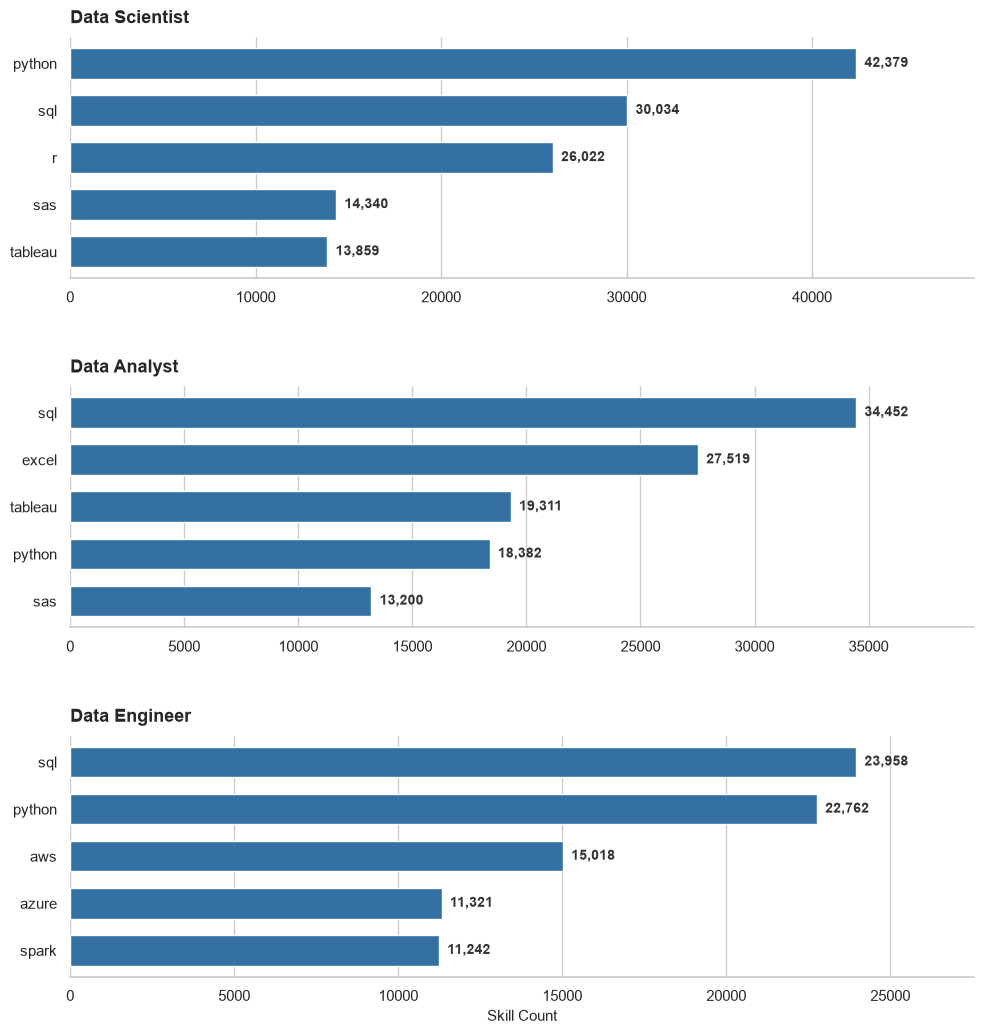

In [35]:
# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Dynamic height based on the number of subplots to avoid overlapping
fig, axes = plt.subplots(
    nrows=len(job_titles), 
    ncols=1, 
    figsize=(10, 3.5 * len(job_titles)), 
    sharex=False
)

# Handle single job title edge case (ensures axes is an array)
if len(job_titles) == 1:
    axes = [axes]

for i, job_title in enumerate(job_titles):
    ax = axes[i]
    
    # Filter top 5 skills and invert order so top skill appears at the TOP of barh
    df_plot = (
        df_skills_count[df_skills_count['job_title_short'] == job_title]
        .head(5)
        .iloc[::-1]
    )
    
    # Plot horizontal bars with custom styling
    bars = ax.barh(
        df_plot['job_skills'], 
        df_plot['skill_count'], 
        color='#3470a3', 
        height=0.65
    )
    
    # Add data labels directly at the end of each bar
    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f'{int(width):,}',
            xy=(width, bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords="offset points",
            ha='left', 
            va='center',
            fontsize=10,
            fontweight='bold',
            color='#333333'
        )
    
    # Titles & Labels
    ax.set_title(job_title, fontsize=13, fontweight='bold', loc='left', pad=10)
    ax.set_xlabel('Skill Count' if i == len(job_titles) - 1 else '', fontsize=11)
    ax.set_ylabel('')
    
    # Aesthetics: Remove top/right/left borders and gridlines on Y
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='y')
    
    # Add room on right for numeric labels
    ax.set_xlim(0, df_plot['skill_count'].max() * 1.15)

# Adjust layout spacing between subplots
plt.tight_layout()
plt.subplots_adjust(hspace=0.45)
plt.show()

In [39]:
df_job_title_count= df_US['job_title_short'].value_counts().reset_index(name='job_count')

In [45]:
df_skill_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')
df_skill_perc['skill_percent'] = 100 * df_skill_perc['skill_count'] / df_skill_perc['job_count']
df_skill_perc

,job_skills,job_title_short,skill_count,job_count,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


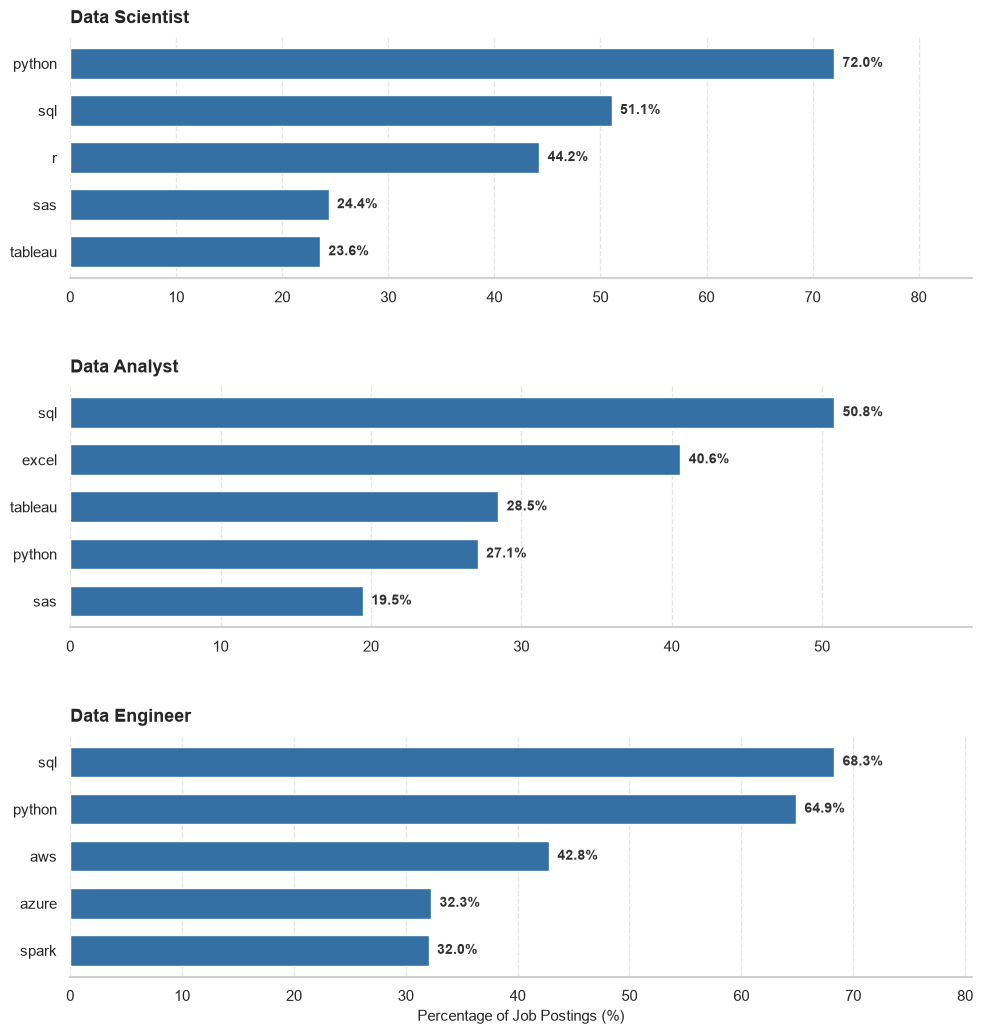

In [48]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    nrows=len(job_titles), 
    ncols=1, 
    figsize=(10, 3.5 * len(job_titles)), 
    sharex=False
)

if len(job_titles) == 1:
    axes = [axes]

for i, job_title in enumerate(job_titles):
    ax = axes[i]
    
    # Filter top 5 skills and invert order so the highest skill is at the top
    df_plot = (
        df_skill_perc[df_skill_perc['job_title_short'] == job_title]
        .head(5)
        .iloc[::-1]
    )
    
    bars = ax.barh(
        df_plot['job_skills'], 
        df_plot['skill_percent'], 
        color='#3470a3', 
        height=0.65
    )
    
    # Format data labels as clean percentages (e.g., 42.5%)
    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f'{width:.1f}%',  # Shows 1 decimal place percentage
            xy=(width, bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords="offset points",
            ha='left', 
            va='center',
            fontsize=10,
            fontweight='bold',
            color='#333333'
        )
    
    # Update title and axis label for percentage
    ax.set_title(job_title, fontsize=13, fontweight='bold', loc='left', pad=10)
    ax.set_xlabel('Percentage of Job Postings (%)' if i == len(job_titles) - 1 else '', fontsize=11)
    ax.set_ylabel('')
    
    # Remove clutter: show x-axis gridlines, hide y-axis gridlines & outer borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Scale x-axis up to 100% or slightly past max value to prevent label overlap
    max_val = df_plot['skill_percent'].max()
    ax.set_xlim(0, max(max_val * 1.18, 10))

plt.tight_layout()
plt.subplots_adjust(hspace=0.45)
plt.show()